# Hand Gesture Detection — YOLOv8 Training Notebook (v4)

**Classes (5):** fist, open palm, peace, thumbs down, thumbs up
*(call me removed — see project log for the experiment history behind this decision)*

**What's different in this version:**
- Uses a **direct ZIP upload** (exported from Roboflow) instead of the Roboflow API/download code
- Reads your class list dynamically from `data.yaml` — no hardcoding, so it automatically reflects your new 5-class setup
- Same confusion matrix + experiment log tracking as before

**Before running:** export your latest Roboflow version as a ZIP (YOLOv8 format) and have it ready to upload in Section 2.

## 1. Install Dependencies

In [ ]:
!pip install ultralytics --quiet

import ultralytics
ultralytics.checks()

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.7/112.6 GB disk)


## 2. Upload and Extract Your Dataset ZIP

Running this cell will open a file picker — select the ZIP file you exported from Roboflow (Versions → Export Dataset → YOLOv8 → Download zip).

In [ ]:
import zipfile
import os

# Path to the uploaded ZIP file
zip_path = "/content/Hand gesture.v3-final.yolov8.zip"

# Folder where the dataset will be extracted
extract_path = "/content/Hand_gesture_dataset"

# Create the extraction directory
os.makedirs(extract_path, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


## 3. Locate and Inspect `data.yaml`

This finds `data.yaml` automatically regardless of how deep it's nested in the extracted zip, and reads your class list directly — so it'll correctly show 5 classes without any manual editing.

In [ ]:
import yaml

data_yaml_path = "/content/Hand_gesture_dataset/data.yaml"

with open(data_yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

CLASS_NAMES = data_config["names"]
print("\nClass order:", CLASS_NAMES)
print("Copy this list EXACTLY into your app.py's CLASS_NAMES if it has changed.")

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 5, 'names': ['fist', 'open palm', 'peace', 'thumbs down', 'thumbs up'], 'roboflow': {'workspace': 'salazars-workspace-f7gct', 'project': 'hand-gesture-mvehd', 'version': 3, 'license': 'Private', 'url': 'https://app.roboflow.com/salazars-workspace-f7gct/hand-gesture-mvehd/3'}}

Class order: ['fist', 'open palm', 'peace', 'thumbs down', 'thumbs up']
Copy this list EXACTLY into your app.py's CLASS_NAMES if it has changed.


## 4. Fix Relative Paths in data.yaml (if needed)

Roboflow's exported `data.yaml` often uses relative paths like `../train/images`, which assume a specific folder depth. Since we extracted the zip fresh, this cell rewrites the paths to be absolute so training doesn't fail with a "file not found" error.

In [ ]:
dataset_root = os.path.dirname(data_yaml_path)

for split in ["train", "val", "test"]:
    if split in data_config:
        # Resolve relative to the data.yaml's own folder
        candidate = os.path.normpath(os.path.join(dataset_root, data_config[split]))
        if os.path.exists(candidate):
            data_config[split] = candidate
        else:
            print(f"Warning: could not resolve path for '{split}': {candidate}")

data_config["path"] = dataset_root

fixed_yaml_path = f"{dataset_root}/data_fixed.yaml"
with open(fixed_yaml_path, "w") as f:
    yaml.dump(data_config, f)

print("Fixed data.yaml saved to:", fixed_yaml_path)
print(data_config)

data_yaml_path = fixed_yaml_path  # use this going forward

Fixed data.yaml saved to: /content/Hand_gesture_dataset/data_fixed.yaml
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 5, 'names': ['fist', 'open palm', 'peace', 'thumbs down', 'thumbs up'], 'roboflow': {'workspace': 'salazars-workspace-f7gct', 'project': 'hand-gesture-mvehd', 'version': 3, 'license': 'Private', 'url': 'https://app.roboflow.com/salazars-workspace-f7gct/hand-gesture-mvehd/3'}, 'path': '/content/Hand_gesture_dataset'}


## 5. Train the Model

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    lr0=0.01,
    name="hand_gesture_yolov8n_v4",
    patience=20,
    verbose=True
)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Hand_gesture_dataset/data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hand_gesture_yolov8n_v4, nbs=64, nms=False, opset=None, optimize=Fal

## 6. Evaluate

In [ ]:
metrics = model.val()

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 782.3±327.9 MB/s, size: 17.4 KB)
val: Scanning /content/Hand_gesture_dataset/valid/labels.cache... 72 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 30.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2it/s 2.3s
                   all         72         67      0.865      0.911      0.942      0.674
                  fist         14         14       0.77      0.959      0.943      0.639
             open palm         12         12      0.913      0.917      0.943       0.64
                 peace         10         10      0.888        0.9      0.962      0.672
           thumbs down          9          9      0.808          1      0.984      0.831
             thumbs up         22         

## 7. Confusion Matrix

Latest run: runs/detect/val


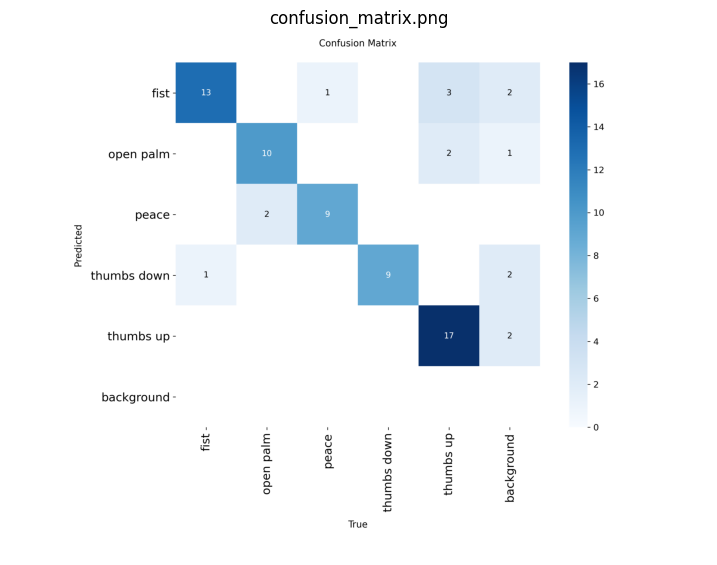

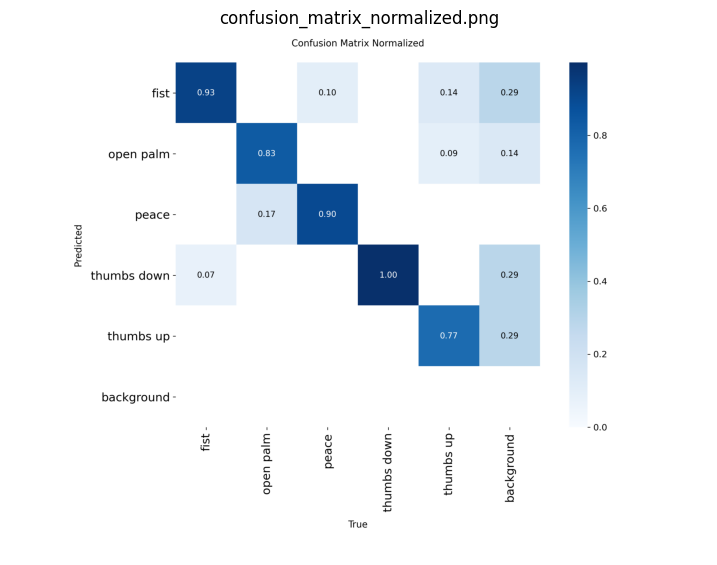

In [ ]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

run_dirs = glob.glob("runs/detect/*")

if not run_dirs:
    print("No training runs found.")
else:
    run_dir = max(run_dirs, key=os.path.getmtime)
    print("Latest run:", run_dir)

    for img_name in ["confusion_matrix.png", "confusion_matrix_normalized.png"]:
        img_path = os.path.join(run_dir, img_name)

        if os.path.exists(img_path):
            plt.figure(figsize=(9, 8))
            plt.imshow(mpimg.imread(img_path))
            plt.axis("off")
            plt.title(img_name)
            plt.show()
        else:
            print(f"{img_name} not found.")

## 8. Sample Predictions on Test Set

In [ ]:
test_images_dir = os.path.join(dataset_root, "test", "images")

pred_results = model.predict(
    source=test_images_dir,
    conf=0.4,
    imgsz=640,
    save=True,
    name="test_predictions_v4"
)

print("Predictions saved to:", pred_results[0].save_dir)


image 1/39 /content/Hand_gesture_dataset/test/images/WhatsApp-Image-2026-07-09-at-1-01-52-PM_jpeg.rf.909cd94161844f513284473ade92cfca.jpg: 640x640 1 peace, 7.5ms
image 2/39 /content/Hand_gesture_dataset/test/images/WhatsApp-Image-2026-07-09-at-11-00-29-PM-1-_jpeg.rf.24999aac9980ea2c71fcae76bc65e219.jpg: 640x640 1 open palm, 9.6ms
image 3/39 /content/Hand_gesture_dataset/test/images/WhatsApp-Image-2026-07-09-at-11-00-32-PM-1-_jpeg.rf.8341777fe807265b2ec6be3aade6d107.jpg: 640x640 1 fist, 7.2ms
image 4/39 /content/Hand_gesture_dataset/test/images/WhatsApp-Image-2026-07-09-at-11-00-45-PM-1-_jpeg.rf.285a365a7c670a688112c61f04170ce2.jpg: 640x640 (no detections), 7.4ms
image 5/39 /content/Hand_gesture_dataset/test/images/WhatsApp-Image-2026-07-09-at-11-00-50-PM_jpeg.rf.4732cc4d0778779ae4cf7b1d0b694368.jpg: 640x640 1 fist, 7.1ms
image 6/39 /content/Hand_gesture_dataset/test/images/WhatsApp-Image-2026-07-09-at-11-50-40-PM_jpeg.rf.fa549a5c915a93729d94fb1fd20dfef8.jpg: 640x640 (no detections), 7

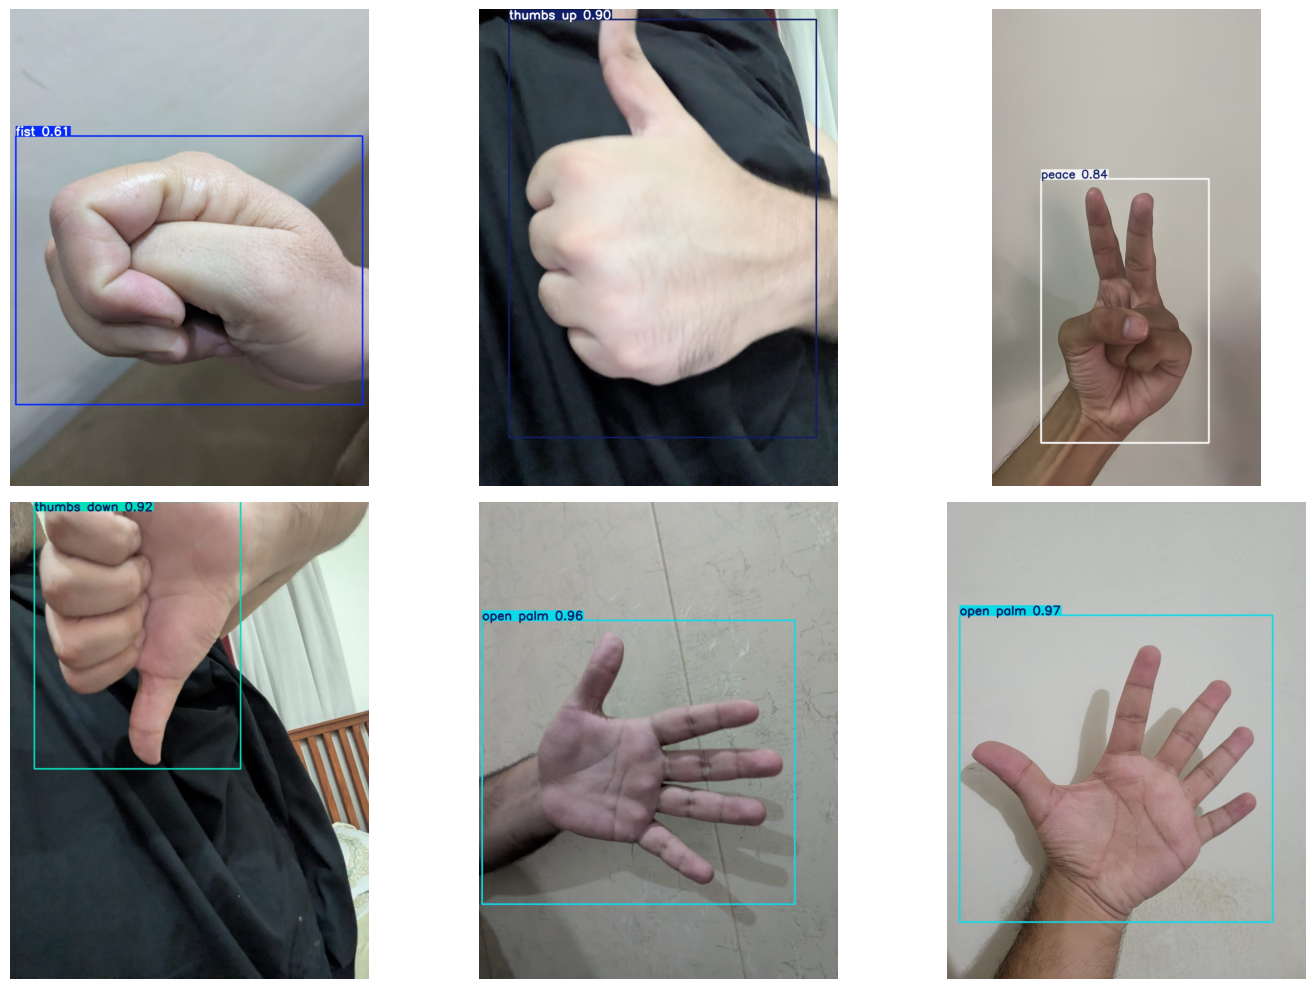

In [ ]:
pred_dir = pred_results[0].save_dir
sample_preds = glob.glob(f"{pred_dir}/*.jpg")[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.flatten(), sample_preds):
    ax.imshow(mpimg.imread(img_path))
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Full Experiment Log (Assignment 7)

| Run | Description | Classes | Precision | Recall | mAP50 | mAP50-95 |
|---|---|---|---|---|---|---|
| 1 | Baseline, 212 train images, imgsz=512 | 6 | 0.908 | 0.840 | 0.901 | 0.608 |
| 2 | Same data, 3x augmentation | 6 | 0.848 | 0.854 | 0.874 | 0.589 |
| 3 | Cleaned dataset + added call_me images | 6 | 0.870 | 0.891 | 0.942 | 0.691 |
| 4 | Same as Run 3, + 2x augmentation | 6 | 0.904 | 0.792 | 0.935 | 0.665 |
| 5 | + negative/background images, imgsz=640 | 6 | 0.900 | 0.857 | 0.923 | 0.651 |
| **6 (this run)** | **call_me removed, 5 classes, imgsz=640** | 5 | | | | |

**Why call_me was removed:** across Runs 1, 3, 4, and 5, `call_me` was consistently the least stable class — its precision swung from 0.584 to 0.896 to 0.721 to 0.665 depending on the intervention, while every other class stabilized quickly with targeted fixes. The confusion matrix (Run 5) also showed persistent confusion between `call_me` and `thumbs_up`, tracing back to inconsistent pinky-finger visibility across training images. Rather than continuing to chase a structurally ambiguous gesture, the class was dropped in favor of the 5 classes that showed reliable, improving performance across every experiment.

## 10. Export the Trained Model

In [ ]:
import os

for root, dirs, files in os.walk("runs/detect"):
    if "best.pt" in files:
        print(os.path.join(root, "best.pt"))

runs/detect/hand_gesture_yolov8n_v4/weights/best.pt
